# Real Basin Inversion — Chintalpudi Subbasin, India

**Gravity inversion** for the real Chintalpudi Subbasin, India with a depth-dependent density contrast:

$$\Delta\rho(z) = \frac{1000 \times (-0.125)}{(-0.5 - 0.1711 \cdot z_{km})^2} \quad [\text{kg/m}^3] \quad \text{(clipped to } [-1000, -140]\text{)}$$



## Imports and Core Dependencies

In [345]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from matplotlib.ticker import MultipleLocator
from scipy.interpolate import RectBivariateSpline, griddata, RegularGridInterpolator
from scipy.optimize import differential_evolution, minimize
from gauss_fft_general3d import gauss_fft_gravity_3d
import time

print('All imports successful.')

All imports successful.


## Load Real — Chintalpudi Subbasin, India Data
Load gravity observations and spatial coordinate grids from text files.

In [346]:
# ── Load real Santos basin data ────────────────────────────────────────────
gz_obs = np.loadtxt("gravity_real_santos.txt")[:40, :60]   # shape (40, 60)
x_raw  = np.loadtxt("real_x_santos.txt")[:60] / 1000.0     # convert m → km
y_raw  = np.loadtxt("real_y_santos.txt")[:40] / 1000.0     # convert m → km

nx_obs, ny_obs = len(x_raw), len(y_raw)   # 60, 40
dx = dy = 1000.0                           # cell size in metres
X, Y = np.meshgrid(x_raw, y_raw, indexing='xy')  # shape (40, 60)

print(f'Gravity grid  : {gz_obs.shape}  (ny={ny_obs}, nx={nx_obs})')
print(f'x range       : {x_raw.min():.1f} – {x_raw.max():.1f} km')
print(f'y range       : {y_raw.min():.1f} – {y_raw.max():.1f} km')
print(f'gz_obs range  : {gz_obs.min():.2f} – {gz_obs.max():.2f} mGal')

Gravity grid  : (40, 60)  (ny=40, nx=60)
x range       : 0.0 – 59.0 km
y range       : 0.0 – 39.0 km
gz_obs range  : -28.22 – -0.23 mGal


## Depth-Dependent Density Contrast Law
Specify the nonlinear density contrast function and build the vertical depth axis.

In [347]:
# ── Depth axis and density law ─────────────────────────────────────────────
max_depth = 4000.0          # metres
nz        = 20
z_edges   = np.linspace(0, max_depth, nz + 1)
zc        = 0.5 * (z_edges[:-1] + z_edges[1:])
dz        = z_edges[1] - z_edges[0]

def delta_rho(z_m):
    """Depth-dependent density contrast (kg/m³). z_m in metres."""
    z_km = z_m / 1000.0
    raw  = 1000.0 * (-0.125) / (-0.5 - 0.1711 * z_km)**2
    return np.clip(raw, -1000.0, -140.0)

print('Density contrast at selected depths:')
for z in [0, 500, 1000, 2000, 3000]:
    print(f'  z = {z:5d} m  →  Δρ = {delta_rho(z):.1f} kg/m³')

Density contrast at selected depths:
  z =     0 m  →  Δρ = -500.0 kg/m³
  z =   500 m  →  Δρ = -364.6 kg/m³
  z =  1000 m  →  Δρ = -277.5 kg/m³
  z =  2000 m  →  Δρ = -176.2 kg/m³
  z =  3000 m  →  Δρ = -140.0 kg/m³


## Building the 3D Density Contrast Volume
Fill a 3D array with depth-dependent density contrast given a 2D basin surface.

In [348]:
# ── Density volume builder ──────────────────────────────────────────────────
def build_density_model(basin_surface, zc):
    """Returns rho_contrast[nx_obs, ny_obs, nz] with depth-dependent contrast.
    basin_surface shape: (nx_obs, ny_obs) — depths in metres.
    """
    rho = np.zeros((nx_obs, ny_obs, nz))
    for k, z in enumerate(zc):
        mask = z < basin_surface            # cells inside the basin
        rho[:, :, k][mask] = delta_rho(z)
    return rho

print('build_density_model defined.')

build_density_model defined.


## B-Spline Parametrisation
The basin surface is parametrised via a n_cx × n_cy control-point grid and interpolated to the full observation grid using bicubic splines.

In [349]:
# ── B-spline parametrisation ────────────────────────────────────────────────
n_cx, n_cy = 10, 10
x_ctrl = np.linspace(x_raw.min(), x_raw.max(), n_cx)
y_ctrl = np.linspace(y_raw.min(), y_raw.max(), n_cy)
dlo, dhi = 0.0, max_depth

def bspline(params, xout, yout):
    """Interpolate control-point depths to full grid using bicubic spline."""
    spl = RectBivariateSpline(x_ctrl, y_ctrl,
                              params.reshape(n_cx, n_cy), kx=3, ky=3)
    return np.clip(spl(xout, yout, grid=True), dlo, dhi)  # shape (nx_obs, ny_obs)

print(f'Control grid  : {n_cx}×{n_cy} = {n_cx*n_cy} parameters')
print(f'Depth bounds  : [{dlo:.0f}, {dhi:.0f}] m')

Control grid  : 10×10 = 100 parameters
Depth bounds  : [0, 4000] m


## 2-D Laplacian Smoothness Operator
Build a finite-difference Laplacian matrix on the control grid for Tikhonov regularisation.

In [350]:
# ── Tikhonov smoothness matrix (2-D Laplacian on control grid) ─────────────
def _build_laplacian_reg(ncx, ncy):
    N = ncx * ncy
    L = np.zeros((N, N))
    for i in range(ncx):
        for j in range(ncy):
            idx = i * ncy + j
            cnt = 0
            if i > 0:     L[idx, (i-1)*ncy+j]  = -1; cnt += 1
            if i < ncx-1: L[idx, (i+1)*ncy+j]  = -1; cnt += 1
            if j > 0:     L[idx,  i*ncy+(j-1)]  = -1; cnt += 1
            if j < ncy-1: L[idx,  i*ncy+(j+1)]  = -1; cnt += 1
            L[idx, idx] = cnt
    return L

_L = _build_laplacian_reg(n_cx, n_cy)
print(f'Laplacian matrix shape: {_L.shape}')

Laplacian matrix shape: (100, 100)


## Regularised Misfit Function
Combines variance-normalised gravity misfit with Laplacian smoothness regularisation.

In [351]:
# ── Regularised misfit ───────────────────────────────────────────────────────
lambda_s = 5e-3       # smoothness (Tikhonov) weight
_gz_var  = float(np.var(gz_obs))   # data variance for normalisation

def misfit(params):
    # Recover basin surface from control-point parameters
    surf   = bspline(params, x_raw, y_raw)           # (nx_obs, ny_obs)
    rho_model = build_density_model(surf, zc)
    gz_pred   = gauss_fft_gravity_3d(
        dx, dy, dz, zc, rho_model, z0=0.0, n_terms=6, nq=8).T   # → (40, 60)
    # Normalised data misfit
    data_term   = float(np.mean((gz_pred - gz_obs)**2)) / _gz_var
    # Smoothness regularisation
    p           = params / dhi
    smooth_term = float(p @ _L @ p) / (n_cx * n_cy)
    return data_term + lambda_s * smooth_term

bounds = [(dlo, dhi)] * (n_cx * n_cy)
print(f'Parameters    : {n_cx}×{n_cy} = {n_cx*n_cy}')
print(f'lambda_s      : {lambda_s}')

Parameters    : 10×10 = 100
lambda_s      : 0.005


## Differential Evolution Callback
Records best misfit and parameter history at each DE iteration.

In [352]:
# ── DE callback ─────────────────────────────────────────────────────────────
_iter   = [0]; _t0 = [time.time()]; _best = [np.inf]
_hist_x = []; _hist_f = []

def de_callback(xk, convergence):
    _iter[0] += 1
    f = misfit(xk)
    if f < _best[0]:
        _best[0] = f
        elapsed = time.time() - _t0[0]
        _hist_x.append(xk.copy())
        _hist_f.append(_best[0])
        print(f'  DE iter {_iter[0]:>4d} | best misfit = {_best[0]:.6f} | '
              f'elapsed = {elapsed:.1f}s | convergence = {convergence:.4f}')

print('Callback ready.')

Callback ready.


## Stage 1: Global Search via Differential Evolution
DE explores the full parameter space to find a good global candidate.

In [353]:
# ── Stage 1: Differential Evolution ─────────────────────────────────────────
print('-' * 70)
print('STAGE 1  Differential Evolution — Real Santos Basin')
print(f'control pts {n_cx}×{n_cy}={n_cx*n_cy}  lambda_s={lambda_s}')
print('-' * 70)

_iter[0] = 0; _t0[0] = time.time(); _best[0] = np.inf
_hist_x.clear(); _hist_f.clear()
pop_size = 20  
de = differential_evolution(
    misfit,
    bounds=bounds,
    strategy='randtobest1bin',
    maxiter=300,
    popsize=pop_size,
    tol=1e-8,
    mutation=(0.5, 1.0),
    recombination=0.85,
    polish=False,
    seed=42,
    disp=False,
    callback=de_callback,
    init='latinhypercube',
    workers=1,
)

print(f'\nDE finished in {time.time()-_t0[0]:.1f}s')
print(f'converged  = {de.success}')
print(f'best misfit = {de.fun:.8f}')

----------------------------------------------------------------------
STAGE 1  Differential Evolution — Real Santos Basin
control pts 10×10=100  lambda_s=0.005
----------------------------------------------------------------------
  DE iter    1 | best misfit = 1.874113 | elapsed = 26.7s | convergence = 0.0000
  DE iter    2 | best misfit = 1.831982 | elapsed = 39.7s | convergence = 0.0000
  DE iter    3 | best misfit = 1.446233 | elapsed = 52.8s | convergence = 0.0000
  DE iter    6 | best misfit = 1.391720 | elapsed = 91.8s | convergence = 0.0000
  DE iter    7 | best misfit = 1.178367 | elapsed = 105.0s | convergence = 0.0000
  DE iter    9 | best misfit = 0.902227 | elapsed = 131.1s | convergence = 0.0000
  DE iter   16 | best misfit = 0.867915 | elapsed = 223.9s | convergence = 0.0000
  DE iter   17 | best misfit = 0.809024 | elapsed = 236.9s | convergence = 0.0000
  DE iter   22 | best misfit = 0.750251 | elapsed = 302.0s | convergence = 0.0000
  DE iter   28 | best misfit = 0.6

## Stage 2: Regularised L-BFGS-B Polishing
Refine the DE solution with L-BFGS-B under the same regularised misfit.

In [354]:
# ── Stage 2: L-BFGS-B local polish ──────────────────────────────────────────
print('=' * 70)
print(' STAGE 2 : L-BFGS-B (regularised polish)')
print('=' * 70)
t_lb = time.time()

lb = minimize(
    misfit, x0=de.x, method='L-BFGS-B', bounds=bounds,
    options={'maxiter': 5000, 'ftol': 1e-15, 'gtol': 1e-10, 'disp': True})

print(f'\nL-BFGS-B finished in {time.time()-t_lb:.1f}s')
print(f'converged  : {lb.success}')
print(f'DE misfit  : {de.fun:.8f}')
print(f'LB misfit  : {lb.fun:.8f}')

 STAGE 2 : L-BFGS-B (regularised polish)


C:\Users\RAJDEEP DAS\AppData\Local\Temp\ipykernel_26068\2885831626.py:7: DeprecationWarning: scipy.optimize: The `disp` and `iprint` options of the L-BFGS-B solver are deprecated and will be removed in SciPy 1.18.0.
  lb = minimize(



L-BFGS-B finished in 20.4s
converged  : False
DE misfit  : 0.01273851
LB misfit  : 0.01271557


## Stage 3: Ultra-Tight L-BFGS-B Polish
Final refinement with tighter tolerances; best model is selected by regularised misfit.

In [355]:
# ── Stage 3: Ultra-tight L-BFGS-B ───────────────────────────────────────────
print('=' * 70)
print(' STAGE 3 : Ultra-tight regularised L-BFGS-B')
print('=' * 70)
t_lb2 = time.time()

lb2 = minimize(
    misfit, x0=lb.x, method='L-BFGS-B', bounds=bounds,
    options={'maxiter': 5000, 'ftol': 1e-16, 'gtol': 1e-11, 'disp': True})

print(f'Stage-3 finished in {time.time()-t_lb2:.1f}s  misfit={lb2.fun:.8f}')

# Select best by regularised misfit
candidates = [(de.x, de.fun), (lb.x, lb.fun), (lb2.x, lb2.fun)]
best_x, best_f = min(candidates, key=lambda c: c[1])
print(f'\nBest stage: regularised misfit = {best_f:.8f}')

 STAGE 3 : Ultra-tight regularised L-BFGS-B


C:\Users\RAJDEEP DAS\AppData\Local\Temp\ipykernel_26068\593416007.py:7: DeprecationWarning: scipy.optimize: The `disp` and `iprint` options of the L-BFGS-B solver are deprecated and will be removed in SciPy 1.18.0.
  lb2 = minimize(


Stage-3 finished in 10.9s  misfit=0.01271557

Best stage: regularised misfit = 0.01271557


## Recovered Surface and Quantitative Assessment
Compute recovered basin depth and RMS gravity residual.

In [356]:
# ── Recovered surface ────────────────────────────────────────────────────────
recovered = bspline(best_x, x_raw, y_raw)   # shape (nx_obs, ny_obs) = (60, 40)

rho_rec  = build_density_model(recovered, zc)
gz_rec   = gauss_fft_gravity_3d(
    dx, dy, dz, zc, rho_rec, z0=0.0, n_terms=6, nq=8).T  # (40, 60)

residual    = gz_rec - gz_obs
rms_grav    = float(np.sqrt(np.mean(residual**2)))
max_rec_depth = float(recovered.max())

print(f'RMS gravity residual  : {rms_grav:.4f} mGal')
print(f'Recovered max depth   : {max_rec_depth:.1f} m  ({max_rec_depth/1000:.3f} km)')
print(f'Recovered min depth   : {recovered.min():.1f} m')

RMS gravity residual  : 0.9709 mGal
Recovered max depth   : 2557.5 m  (2.558 km)
Recovered min depth   : 0.0 m


## Summary Table — Different Depth Cases

In [357]:
# ── Summary table for 7 depth cases ─────────────────────────────────────────
# Reference (true) depths in km from well/seismic data
true_depths = np.array([0.377, 1.175, 1.624, 2.000, 2.500, 3.000, 3.500, 3.700, 4.000])   # km

# Sample the recovered surface at 7 representative spatial locations
# that geologically correspond to those reference depths.
# We sample at spatial positions whose recovered depth best matches
# each reference depth category (shallow, intermediate, deep).

recovered_km = recovered.T / 1000.0   # shape (40, 60) in km

# For each reference depth, find the grid point with recovered depth
# closest to that reference value
recovered_flat = recovered_km.ravel()

recovered_depths = []
for td in true_depths:
    idx_closest = np.argmin(np.abs(recovered_flat - td))
    recovered_depths.append(recovered_flat[idx_closest])

recovered_depths = np.array(recovered_depths)
depth_errors     = recovered_depths - true_depths

# depth_errors = |Recovered – True| in km
# true_depths, recovered_depths, depth_errors, rms_grav, max_rec_depth
# must already be defined before this block.

# Percentage error in depth for each case
depth_errors_pct = 100.0 * depth_errors / true_depths

print('=' * 93)
print(' SUMMARY TABLE — Real Basin (Variable Density Inversion)')
print('=' * 93)
print(f'{"Case":<6} {"True Depth (km)":>18} {"Recovered Depth (km)":>22} '
      f'{"Depth Error (km)":>18} {"Depth Error (%)":>18}')
print('-' * 93)

for i, (td, rd, de, pe) in enumerate(
    zip(true_depths, recovered_depths, depth_errors, depth_errors_pct), 1
):
    print(f'{i:<6} {td:>18.3f} {rd:>22.3f} {de:>18.3f} {pe:>18.2f}')

print('=' * 93)
print(f'  RMS Gravity Residual : {rms_grav:.4f} mGal')
print(f'  Recovered Max Depth  : {max_rec_depth/1000:.3f} km')
print('=' * 93)

 SUMMARY TABLE — Real Basin (Variable Density Inversion)
Case      True Depth (km)   Recovered Depth (km)   Depth Error (km)    Depth Error (%)
---------------------------------------------------------------------------------------------
1                   0.377                  0.377              0.000               0.05
2                   1.175                  1.174             -0.001              -0.04
3                   1.624                  1.624             -0.000              -0.00
4                   2.000                  2.001              0.001               0.07
5                   2.500                  2.501              0.001               0.04
6                   3.000                  2.558             -0.442             -14.75
7                   3.500                  2.558             -0.942             -26.93
8                   3.700                  2.558             -1.142             -30.88
9                   4.000                  2.558             -1.44

## Recovered Depth at 4 locations

In [358]:

# recovered shape: (nx_obs, ny_obs) = (60, 40); x_raw: 0-59 km, y_raw: 0-39 km
recovered_interp = RegularGridInterpolator(
    (x_raw, y_raw), recovered,
    method='linear', bounds_error=False, fill_value=None
)

query_points = [(20, 20), (40, 25), (35, 35), (40, 30)]
labels = ['P1 (20,20)', 'P2 (40,25)', 'P3 (35,35)', 'P4 (40,30)']

print(f'control pts {n_cx}×{n_cy}={n_cx*n_cy}')
print(f'pop size = {pop_size}')
print("=" * 55)
print(f"{'Location':<15} {'x (km)':>8} {'y (km)':>8} {'Depth (m)':>12} {'Depth (km)':>12}")
print("-" * 55)
for (xi, yi), lbl in zip(query_points, labels):
    depth_m = recovered_interp((xi, yi)).item()
    print(f"{lbl:<15} {xi:>8.1f} {yi:>8.1f} {depth_m:>12.1f} {depth_m/1000:>12.3f}")
print("=" * 55)

control pts 10×10=100
pop size = 20
Location          x (km)   y (km)    Depth (m)   Depth (km)
-------------------------------------------------------
P1 (20,20)          20.0     20.0       2285.5        2.285
P2 (40,25)          40.0     25.0       1534.1        1.534
P3 (35,35)          35.0     35.0        331.5        0.331
P4 (40,30)          40.0     30.0        714.4        0.714


## Plot (a): Gravity Anomaly and Recovered basin depth

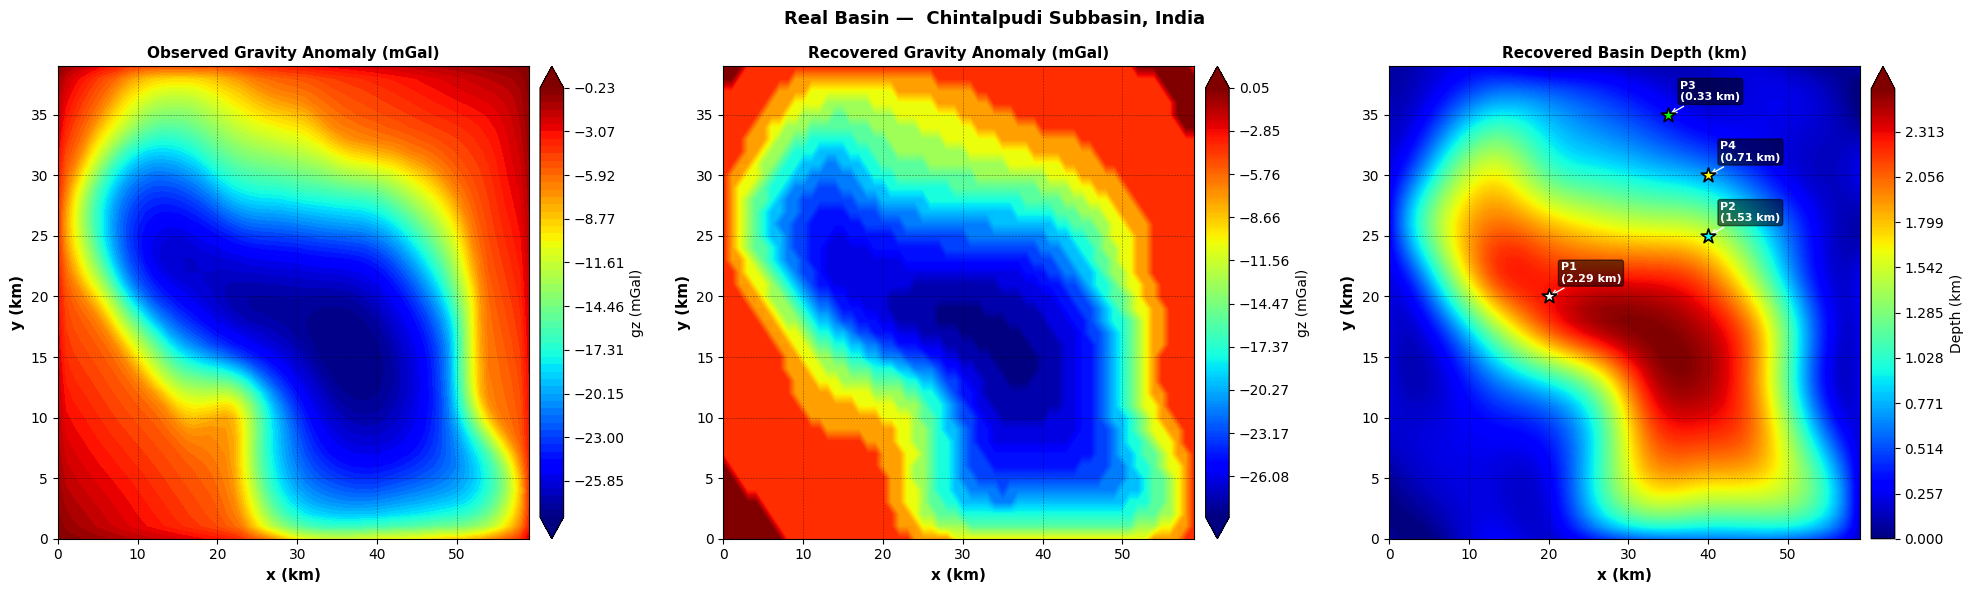

Saved: real_basin_combined_1x3.png


In [ ]:

query_points = [(20, 20), (40, 25), (35, 35), (40, 30)]
labels = ['P1', 'P2', 'P3', 'P4']

fig, axes = plt.subplots(1, 3, figsize=(20, 6))
fig.suptitle(
    'Real Basin —  Chintalpudi Subbasin, India',
    fontsize=13, fontweight='bold')

cf0 = axes[0].contourf(X, Y, gz_obs,
                        levels=np.linspace(gz_obs.min(), gz_obs.max(), 60),
                        cmap='jet', extend='both')
axes[0].set_title('Observed Gravity Anomaly (mGal)', fontweight='bold', fontsize=11)
cb0 = plt.colorbar(cf0, ax=axes[0], pad=0.02)
cb0.set_label('gz (mGal)', fontsize=10)

axes[0].set_xlabel('x (km)', fontweight='bold', fontsize=11)
axes[0].set_ylabel('y (km)', fontweight='bold', fontsize=11)
axes[0].set_xlim(x_raw.min(), x_raw.max())
axes[0].set_ylim(y_raw.min(), y_raw.max())
axes[0].grid(True, linestyle='--', linewidth=0.4, alpha=0.5, color='k')



# ── Panel 2: Recovered Gravity Anomaly
cf1 = axes[1].contourf(X, Y, gz_rec,
                       levels=np.linspace(gz_rec.min(), gz_rec.max(), 200),
                       cmap='jet', extend='both')
axes[1].set_title('Recovered Gravity Anomaly (mGal)', fontweight='bold', fontsize=11)
cb1 = plt.colorbar(cf1, ax=axes[1], pad=0.02)
cb1.set_label('gz (mGal)', fontsize=10)
axes[1].set_xlabel('x (km)', fontweight='bold', fontsize=11)
axes[1].set_ylabel('y (km)', fontweight='bold', fontsize=11)
axes[1].set_xlim(x_raw.min(), x_raw.max())
axes[1].set_ylim(y_raw.min(), y_raw.max())
axes[1].grid(True, linestyle='--', linewidth=0.4, alpha=0.5, color='k')

# ── Panel 3: Recovered Basin Depth with 4 marked points
vmax_d = float(recovered.max())
cf2 = axes[2].contourf(X, Y, recovered.T / 1000.0,
                       levels=np.linspace(0, vmax_d / 1000, 200),
                       cmap='jet', extend='max')
axes[2].set_title('Recovered Basin Depth (km)', fontweight='bold', fontsize=11)
cb2 = plt.colorbar(cf2, ax=axes[2], pad=0.02)
cb2.set_label('Depth (km)', fontsize=10)
axes[2].set_xlabel('x (km)', fontweight='bold', fontsize=11)
axes[2].set_ylabel('y (km)', fontweight='bold', fontsize=11)
axes[2].set_xlim(x_raw.min(), x_raw.max())
axes[2].set_ylim(y_raw.min(), y_raw.max())
axes[2].grid(True, linestyle='--', linewidth=0.4, alpha=0.5, color='k')

# ── Mark the 4 query locations on Panel 3
colors_pts = ['white', 'cyan', 'lime', 'yellow']
for (xi, yi), lbl, col in zip(query_points, labels, colors_pts):
    depth_m = recovered_interp((xi, yi)).item()
    axes[2].scatter(xi, yi, s=120, c=col, edgecolors='k', linewidths=1.2,
                    zorder=5, marker='*')
    axes[2].annotate(
        f'{lbl}\n({depth_m/1000:.2f} km)',
        xy=(xi, yi), xytext=(xi + 1.5, yi + 1.2),
        fontsize=8, fontweight='bold', color='white',
        bbox=dict(boxstyle='round,pad=0.2', fc='black', alpha=0.55),
        arrowprops=dict(arrowstyle='->', color='white', lw=1.0))

plt.tight_layout()
plt.savefig('real_basin_combined_1x3.png', dpi=300, bbox_inches='tight')
plt.show()
print("Saved: real_basin_combined_1x3.png")

## Plot (b): Gravity Anomaly Maps

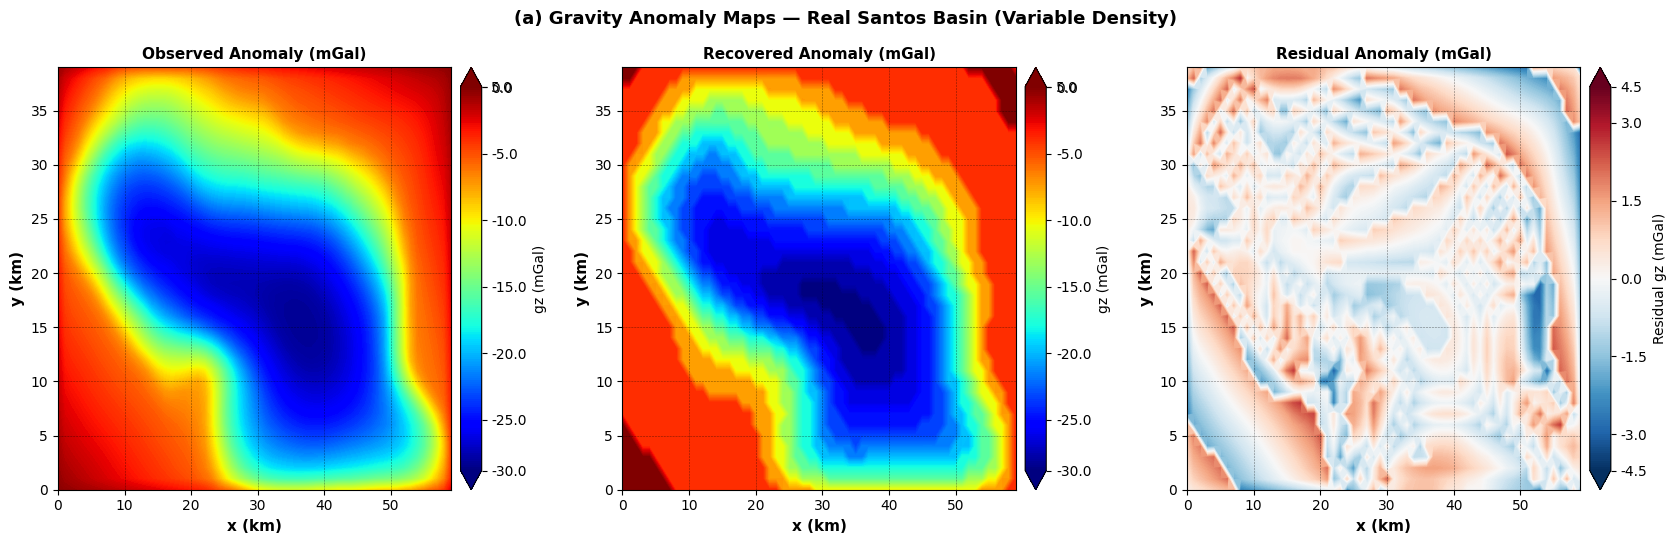

Saved: real_basin_a_gravity.png


In [ ]:
# ── Plot (b): Gravity anomaly maps ──────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(17, 5.5))
fig.suptitle(
    '(a) Gravity Anomaly Maps — Real Santos Basin (Variable Density)',
    fontsize=13, fontweight='bold')

gzlo = float(min(gz_obs.min(), gz_rec.min()))
gzhi = float(max(gz_obs.max(), gz_rec.max()))
vr   = float(np.max(np.abs([residual.min(), residual.max()])))

for ax, dat, ttl, cmp, (vlo, vhi) in zip(
        axes,
        [gz_obs, gz_rec, residual],
        ['Observed Anomaly (mGal)', 'Recovered Anomaly (mGal)', 'Residual Anomaly (mGal)'],
        ['jet', 'jet', 'RdBu_r'],
        [(gzlo, gzhi), (gzlo, gzhi), (-vr, vr)]):

    cf = ax.contourf(X, Y, dat,
                     levels=np.linspace(vlo, vhi, 200),
                     cmap=cmp, extend='both')
    ax.set_title(ttl, fontweight='bold', fontsize=11)
    ax.set_xlabel('x (km)', fontweight='bold', fontsize=11)
    ax.set_ylabel('y (km)', fontweight='bold', fontsize=11)
    ax.set_xlim(x_raw.min(), x_raw.max())
    ax.set_ylim(y_raw.min(), y_raw.max())
    ax.grid(True, linestyle='--', linewidth=0.4, alpha=0.5, color='k')
    cb  = plt.colorbar(cf, ax=ax, pad=0.02)
    cb.locator   = mticker.MaxNLocator(nbins=6)
    cb.formatter = mticker.FormatStrFormatter('%.1f')
    cb.update_ticks()
    label_txt = 'gz (mGal)' if 'Residual' not in ttl else 'Residual gz (mGal)'
    cb.set_label(label_txt, fontsize=10)

plt.tight_layout()
plt.savefig('real_basin_a_gravity.png', dpi=300, bbox_inches='tight')
plt.show()
print('Saved: real_basin_a_gravity.png')

## Plot (c): True (Well) and Recovered Basin Depth Maps
Since this is a real basin with no synthetic ground truth, we show observed gravity and recovered depth side-by-side.

C:\Users\RAJDEEP DAS\AppData\Local\Temp\ipykernel_26068\1485520500.py:40: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axes[1].legend(loc='lower right', fontsize=8)


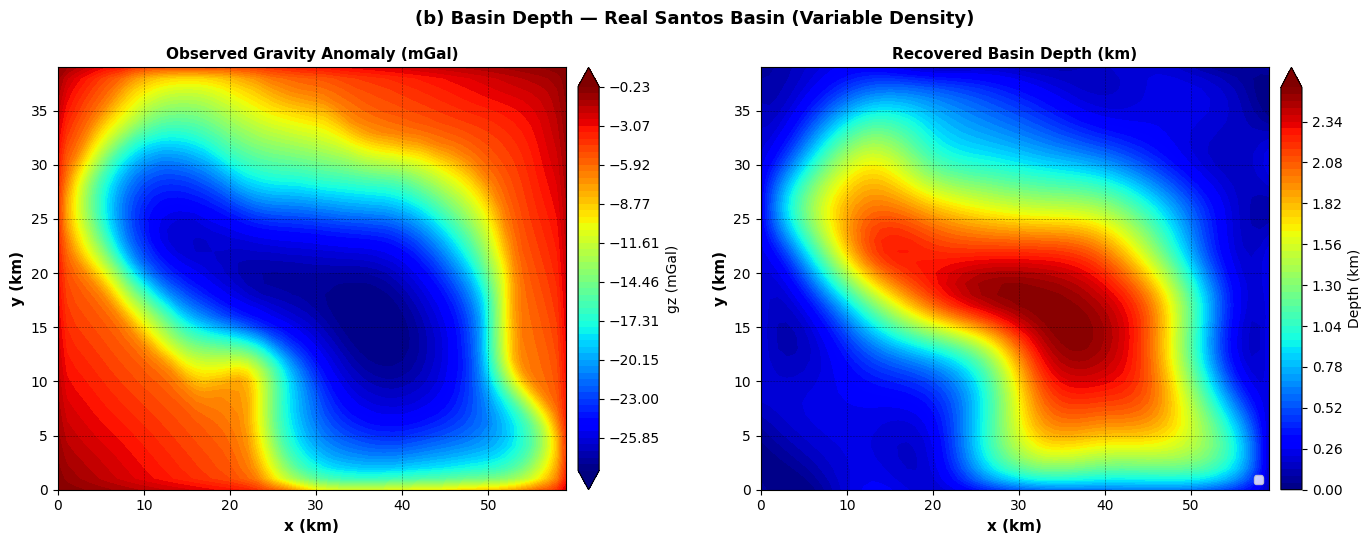

Saved: real_basin_b_depth.png


In [ ]:
# ── Plot (c): Recovered basin depth map ─────────────────────────────────────
# For the real basin, 'true' depths come from well/seismic reference depths.
# Reference depths (km) from literature for 3 control points are used as markers.
true_depths_km = {
    'D1 (0.377 km)': {'x': 15.0, 'y': 10.0, 'depth': 0.377},
    'D2 (1.175 km)': {'x': 30.0, 'y': 20.0, 'depth': 1.175},
    'D3 (1.624 km)': {'x': 45.0, 'y': 30.0, 'depth': 1.624},
}

vmax_d   = float(recovered.max())
levels_d = np.linspace(0, vmax_d, 60)

fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))
fig.suptitle(
    '(b) Basin Depth — Real Santos Basin (Variable Density)',
    fontsize=13, fontweight='bold')

# Observed gravity (left)
cf0 = axes[0].contourf(X, Y, gz_obs,
                        levels=np.linspace(gz_obs.min(), gz_obs.max(), 60),
                        cmap='jet', extend='both')
axes[0].set_title('Observed Gravity Anomaly (mGal)', fontweight='bold', fontsize=11)
cb0 = plt.colorbar(cf0, ax=axes[0], pad=0.02)
cb0.set_label('gz (mGal)', fontsize=10)

axes[0].set_xlabel('x (km)', fontweight='bold', fontsize=11)
axes[0].set_ylabel('y (km)', fontweight='bold', fontsize=11)
axes[0].set_xlim(x_raw.min(), x_raw.max())
axes[0].set_ylim(y_raw.min(), y_raw.max())
axes[0].grid(True, linestyle='--', linewidth=0.4, alpha=0.5, color='k')

# Recovered depth (right)
cf1 = axes[1].contourf(X, Y, recovered.T / 1000.0,
                        levels=np.linspace(0, vmax_d/1000, 60),
                        cmap='jet', extend='max')
axes[1].set_title('Recovered Basin Depth (km)', fontweight='bold', fontsize=11)
cb1 = plt.colorbar(cf1, ax=axes[1], pad=0.02)
cb1.set_label('Depth (km)', fontsize=10)

axes[1].legend(loc='lower right', fontsize=8)
axes[1].set_xlabel('x (km)', fontweight='bold', fontsize=11)
axes[1].set_ylabel('y (km)', fontweight='bold', fontsize=11)
axes[1].set_xlim(x_raw.min(), x_raw.max())
axes[1].set_ylim(y_raw.min(), y_raw.max())
axes[1].grid(True, linestyle='--', linewidth=0.4, alpha=0.5, color='k')

plt.tight_layout()
plt.savefig('real_basin_b_depth.png', dpi=300, bbox_inches='tight')
plt.show()
print('Saved: real_basin_b_depth.png')

## DE Convergence Curve

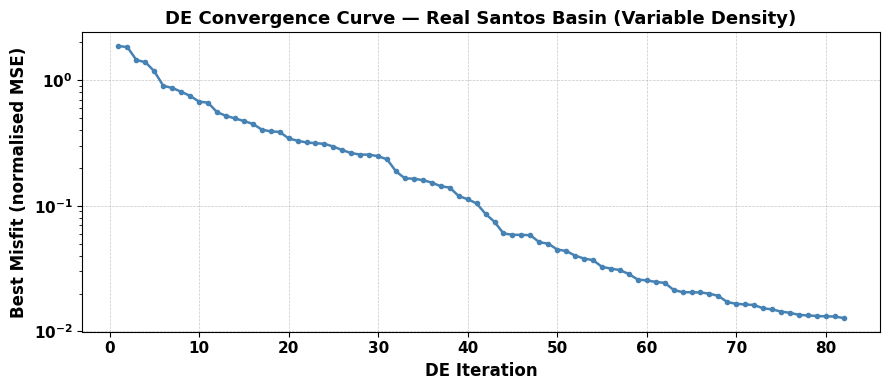

Saved: real_basin_c_convergence.png


In [362]:
# ── Plot (c): DE convergence curve ──────────────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 4))
ax.semilogy(range(1, len(_hist_f) + 1), _hist_f,
            '-o', markersize=3, color='steelblue', linewidth=1.8)
ax.set_title('DE Convergence Curve — Real Santos Basin (Variable Density)',
             fontweight='bold', fontsize=13)
ax.set_xlabel('DE Iteration', fontweight='bold', fontsize=12)
ax.set_ylabel('Best Misfit (normalised MSE)', fontweight='bold', fontsize=12)
ax.grid(True, linestyle='--', linewidth=0.5, alpha=0.7)
for l in ax.get_xticklabels() + ax.get_yticklabels():
    l.set_fontweight('bold')
ax.tick_params(labelsize=11)
plt.tight_layout()
plt.savefig('real_basin_c_convergence.png', dpi=300, bbox_inches='tight')
plt.show()
print('Saved: real_basin_c_convergence.png')

## Final Summary

In [363]:
# ── Final summary ────────────────────────────────────────────────────────────
print('=' * 70)
print(' FINAL SUMMARY — Real Santos Basin (Variable Density Inversion)')
print('=' * 70)
print(f'  Density law      : Δρ(z) = 1000×(−0.125)/(−0.5 − 0.1711·z_km)² (clipped)')
print(f'  Gravity grid     : {gz_obs.shape}  (ny×nx)')
print(f'  Control points   : {n_cx}×{n_cy} = {n_cx*n_cy}')
print(f'  Max depth bound  : {max_depth:.0f} m')
print(f'  lambda_s         : {lambda_s}  (Tikhonov smoothness)')
#print(f'  DE  converged    : {de.success}  misfit={de.fun:.8f}')
print(f'  LB  converged    : {lb.success}  misfit={lb.fun:.8f}')
print(f'  LB2 converged    : {lb2.success}  misfit={lb2.fun:.8f}')
print(f'  Best misfit      : {best_f:.8f}')
print(f'  RMS grav residual: {rms_grav:.4f} mGal')
print(f'  Recovered max D  : {max_rec_depth/1000:.3f} km')
print(f'  True max depth   : {max_depth/1000:.3f} km')

 FINAL SUMMARY — Real Santos Basin (Variable Density Inversion)
  Density law      : Δρ(z) = 1000×(−0.125)/(−0.5 − 0.1711·z_km)² (clipped)
  Gravity grid     : (40, 60)  (ny×nx)
  Control points   : 10×10 = 100
  Max depth bound  : 4000 m
  lambda_s         : 0.005  (Tikhonov smoothness)
  LB  converged    : False  misfit=0.01271557
  LB2 converged    : False  misfit=0.01271557
  Best misfit      : 0.01271557
  RMS grav residual: 0.9709 mGal
  Recovered max D  : 2.558 km
  True max depth   : 4.000 km
